***
## Pandas (Data Maniplulation)
***

In [14]:
import pandas as pd
import numpy as np
print(f'version = {pd.__version__}')

version = 3.0.2


***
## How to read ?
***

**Pandas 常用讀取函式**

| 函式 | 用途 | 常用參數 |
|------|------|---------|
| `pd.read_csv(path)` | 讀 CSV | `index_col`, `usecols`, `dtype`, `parse_dates` |
| `pd.read_excel(path, sheet_name)` | 讀 Excel | `sheet_name=0` 為第一張表；`sheet_name=None` 全部 |
| `pd.read_csv(path, header=None)` | 讀無標頭 TXT | 搭配 `sep` 指定分隔符 |

**Gotcha：** `read_excel` 預設讀第一張工作表（`sheet_name=0`）；
若 Excel 含多張表，`sheet_name=None` 會回傳 `dict[str, DataFrame]`，而非單一 DataFrame。


In [15]:
import os
folder_path = r'Pandas Read Files-20260423'

# read_csv: auto-detects header from the first row by default
df_csv = pd.read_csv(os.path.join(folder_path, 'username.csv'))
# sep=';' overrides the default comma delimiter
df_csv_sep = pd.read_csv(os.path.join(folder_path, 'username.csv'), sep=';')
display(df_csv,
        df_csv_sep)


,Username; Identifier;First name;Last name
0,booker12;9012;Rachel;Booker
1,grey07;2070;Laura;Grey
2,johnson81;4081;Craig;Johnson
3,jenkins46;9346;Mary;Jenkins
4,smith79;5079;Jamie;Smith


,Username,Identifier,First name,Last name
0,booker12,9012,Rachel,Booker
1,grey07,2070,Laura,Grey
2,johnson81,4081,Craig,Johnson
3,jenkins46,9346,Mary,Jenkins
4,smith79,5079,Jamie,Smith


In [16]:
# sheet_name=0 (default): read the first worksheet
df_sht = pd.read_excel(os.path.join(folder_path, 'Carbon emission data.xlsx'))
# sheet_name=None: returns a dict-like object keyed by sheet names
df_full = pd.read_excel(os.path.join(folder_path, 'Carbon emission data.xlsx'),
                        sheet_name=None)
display(df_sht,
        df_full)


,mL CH4/h,SC,SF,SP,SFP,DC,DF,DP,DFP
0,7 d,4.67,4.81,3.79,2.92,5.10,4.96,3.65,3.06
1,14 d,4.52,4.81,3.50,2.33,4.96,4.38,2.77,2.19
2,21 d,2.33,2.04,1.60,0.73,3.21,2.77,2.19,1.75
3,28 d,1.75,1.90,1.17,0.88,2.77,3.06,1.75,0.88
4,35 d,0.88,0.88,1.02,0.88,2.63,2.33,2.33,0.44
5,42 d,0.73,0.88,0.88,0.58,0.44,0.73,0.88,0.73


{'Carbon emission':   mL CH4/h    SC    SF    SP   SFP    DC    DF    DP   DFP
 0      7 d  4.67  4.81  3.79  2.92  5.10  4.96  3.65  3.06
 1     14 d  4.52  4.81  3.50  2.33  4.96  4.38  2.77  2.19
 2     21 d  2.33  2.04  1.60  0.73  3.21  2.77  2.19  1.75
 3     28 d  1.75  1.90  1.17  0.88  2.77  3.06  1.75  0.88
 4     35 d  0.88  0.88  1.02  0.88  2.63  2.33  2.33  0.44
 5     42 d  0.73  0.88  0.88  0.58  0.44  0.73  0.88  0.73,
 'Carbon markets':     Month and Year  AAU    CER  ERU RMU       NZU     Total
 0       2008-01-01    0    0.0    0   0         0         0
 1       2008-02-01    0    0.0    0   0         0         0
 2       2008-03-01    0  108.0    0   0         0       108
 3       2008-04-01    0   20.0    0   0         0        20
 4       2008-05-01    0    0.0    0   0         0         0
 ..             ...  ...    ...  ...  ..       ...       ...
 201     2024-10-01    0    0.0    0   0  18312569  18312569
 202     2024-11-01    0    0.0    0   0  12314765  12

In [17]:
# Read from txt by directly pandas
df_txt = pd.read_csv(os.path.join(folder_path,'emails.txt'),header = None)
df_txt.head()

,0
0,asmith@gmail.com
1,ajohnson@gmail.com
2,awilliams@gmail.com
3,ajones@gmail.com
4,abrown@gmail.com


In [18]:
# read text with open
dL = []
with open(os.path.join(folder_path,'emails.txt')) as f:
    for row in f.readlines():
        dL.append(row.replace('\n',''))
dL[:5]

['asmith@gmail.com',
 'ajohnson@gmail.com',
 'awilliams@gmail.com',
 'ajones@gmail.com',
 'abrown@gmail.com']

In [19]:
# 延伸：read_csv 常用進階參數
import pandas as pd

# usecols：只讀特定欄，節省記憶體
# dtype：預先指定型別，避免自動推斷錯誤（如 zipcode 被讀成 int）
# parse_dates：自動將指定欄轉成 datetime

# 範例（以虛構路徑示範）
# df = pd.read_csv('data.csv',
#                  usecols=['date', 'value'],
#                  dtype={'value': float},
#                  parse_dates=['date'],
#                  index_col='date')

# 若 CSV 沒有 header：
# df = pd.read_csv('data.csv', header=None, names=['col1','col2','col3'])

# 讀取大型檔案（分批）：
# for chunk in pd.read_csv('big.csv', chunksize=10000):
#     process(chunk)
print("read_csv 進階參數範例（取消註解後使用）")


read_csv 進階參數範例（取消註解後使用）


***
## Pandas Series as 1-dim Array
***

**Pandas Series — 帶標籤的一維陣列**

```python
pd.Series(data, index=index)


In [20]:
# pd.Series: the first argument is data, index= assigns labels
data = pd.Series([np.exp(k) for k in range(4)],
                 index=[f'exp({k})' for k in range(4)])
# labeled index makes alignment and lookup more readable
display(data,
        data.values,  # underlying NumPy array
        data.index,
        data[1:3],  # positional slice on the existing order
        data['exp(2)'])


exp(0)     1.000000
exp(1)     2.718282
exp(2)     7.389056
exp(3)    20.085537
dtype: float64

array([ 1.        ,  2.71828183,  7.3890561 , 20.08553692])

Index(['exp(0)', 'exp(1)', 'exp(2)', 'exp(3)'], dtype='str')

exp(1)    2.718282
exp(2)    7.389056
dtype: float64

np.float64(7.38905609893065)

In [21]:
# dict -> Series: keys automatically become the index labels
score_sheet = {'Leborn James': 41131,
               'Kobe Bryant': 33643,
               'Michael Jordan': 32292,
               'Dirk Nowitzki': 31560,
               'Kevin Durant': 29505,
               'Tim Duncan': 26496}
data = pd.Series(score_sheet)
# label-based lookup uses player names; iloc still uses positions
display(data,
        data['Kobe Bryant'],
        data['Kobe Bryant':'Kevin Durant'])


Leborn James      41131
Kobe Bryant       33643
Michael Jordan    32292
Dirk Nowitzki     31560
Kevin Durant      29505
Tim Duncan        26496
dtype: int64

np.int64(33643)

Kobe Bryant       33643
Michael Jordan    32292
Dirk Nowitzki     31560
Kevin Durant      29505
dtype: int64

In [22]:
# 延伸：Series 的常用屬性與操作
import pandas as pd
import numpy as np

s = pd.Series([10, 20, 30, 40], index=['a', 'b', 'c', 'd'])

print(s.values)        # ndarray：[10 20 30 40]
print(s.index)         # Index(['a','b','c','d'])
print(s.dtype)         # int64
print(s.name)          # None（可用 s.name = 'score' 命名）

# 向量化運算：直接對整個 Series 操作（不用迴圈）
print(s * 2)           # 每個值乘以 2，index 保留
print(s[s > 15])       # 布林索引：只取大於 15 的元素

# 常用統計
print(s.describe())    # count, mean, std, min, 25%, 50%, 75%, max
print(s.value_counts()) # 頻率計數（對類別型資料很有用）


[10 20 30 40]
Index(['a', 'b', 'c', 'd'], dtype='str')
int64
None
a    20
b    40
c    60
d    80
dtype: int64
b    20
c    30
d    40
dtype: int64
count     4.000000
mean     25.000000
std      12.909944
min      10.000000
25%      17.500000
50%      25.000000
75%      32.500000
max      40.000000
dtype: float64
10    1
20    1
30    1
40    1
Name: count, dtype: int64


***
## Pandas DataFrame as Generalized 2-dim NumPy Array
***

**Pandas DataFrame — 帶標籤的二維表格**

可視為「Series 的字典」：每一欄是一個 Series，共用同一個 row index。

建立方式：
- `pd.DataFrame(dict_of_lists)` — key → 欄名，list → 欄資料
- `pd.DataFrame(list_of_dicts)` — 每個 dict 是一行
- `pd.DataFrame(ndarray, columns=..., index=...)` — 從 NumPy array

**Gotcha：** `df['col']` 回傳 Series；`df[['col']]` 回傳 DataFrame（shape 不同！）
在後續 merge、concat 時 shape 差異會影響結果。


In [23]:
game_sheet = {'Leborn James':1520,
              'Kobe Bryant':1346,
              'Michael Jordan':1072,
              'Dirk Nowitzki':1522,
              'Kevin Durant':1082,
              'Tim Duncan':1392}
mdf = pd.DataFrame({'Score':score_sheet,
                    'Game':game_sheet})
display(mdf,
        mdf.index,
        mdf.columns,
        mdf['Game'], # ditionary-style access
        mdf.Game) # attribute-style access

,Score,Game
Leborn James,41131,1520
Kobe Bryant,33643,1346
Michael Jordan,32292,1072
Dirk Nowitzki,31560,1522
Kevin Durant,29505,1082
Tim Duncan,26496,1392


Index(['Leborn James', 'Kobe Bryant', 'Michael Jordan', 'Dirk Nowitzki',
       'Kevin Durant', 'Tim Duncan'],
      dtype='str')

Index(['Score', 'Game'], dtype='str')

Leborn James      1520
Kobe Bryant       1346
Michael Jordan    1072
Dirk Nowitzki     1522
Kevin Durant      1082
Tim Duncan        1392
Name: Game, dtype: int64

Leborn James      1520
Kobe Bryant       1346
Michael Jordan    1072
Dirk Nowitzki     1522
Kevin Durant      1082
Tim Duncan        1392
Name: Game, dtype: int64

In [24]:
# 延伸：DataFrame 的常用屬性
import pandas as pd
import numpy as np

df = pd.DataFrame({'A': [1, 2, 3], 'B': [4.0, 5.0, 6.0]},
                  index=['r1', 'r2', 'r3'])

print(df.shape)        # (3, 2)
print(df.dtypes)       # A: int64, B: float64
print(df.columns)      # Index(['A','B'])
print(df.index)        # Index(['r1','r2','r3'])
print(df.values)       # ndarray（失去標籤）

# df['A'] vs df[['A']]
print(type(df['A']))   # Series
print(type(df[['A']])) # DataFrame — 差在外層多一對 []

# 轉置（行列互換）
print(df.T)


(3, 2)
A      int64
B    float64
dtype: object
Index(['A', 'B'], dtype='str')
Index(['r1', 'r2', 'r3'], dtype='str')
[[1. 4.]
 [2. 5.]
 [3. 6.]]
<class 'pandas.Series'>
<class 'pandas.DataFrame'>
    r1   r2   r3
A  1.0  2.0  3.0
B  4.0  5.0  6.0


***
## Pandas Index is immutable
***

In [25]:
data = pd.Series([np.exp(k) for k in range(4)])
try:
    data.index[1] = 2
except Exception as e:
    print(e)

Index does not support mutable operations


In [26]:
data = pd.Series([2**k for k in range(4)],
                 index = [f'a{k}' for k in range(4)])
display(data,
        'a0' in data, # examine the indice
        data.keys(),
        list(data.items()))

a0    1
a1    2
a2    4
a3    8
dtype: int64

True

Index(['a0', 'a1', 'a2', 'a3'], dtype='str')

[('a0', 1), ('a1', 2), ('a2', 4), ('a3', 8)]

In [27]:
# Extend a Series by assigning to a new index value
data['a4'] = 16
display(data,
        data[(data > 3) & (data < 10)], # masking
        data[['a1','a4']]) # fancy indexing

a0     1
a1     2
a2     4
a3     8
a4    16
dtype: int64

a2    4
a3    8
dtype: int64

a1     2
a4    16
dtype: int64

***
## Indexers : iloc and loc
***

**`loc` vs `iloc` — pandas 兩大索引器**

| 索引器 | 依據 | 終點含不含 |
|--------|------|-----------|
| `loc[label]` | **標籤**（index 的值） | **含**終點 |
| `iloc[position]` | **整數位置**（0-based） | **不含**終點（同 Python slice） |

```python
s = pd.Series(list('abcde'), index=[1, 2, 3, 5, 9])
s.loc[3]     # → 'c'（標籤 3）
s.iloc[3]    # → 'd'（位置 3，即第 4 個）
s.loc[1:3]   # → index 1,2,3（含終點 3）
s.iloc[1:3]  # → 位置 1,2（不含位置 3）


In [28]:
# loc: label-based indexing, slicing includes both endpoints
# iloc: position-based indexing, slicing excludes the stop position
data = pd.Series(list('abcde'), index=[1, 2, 3, 5, 9])
display(data,
        data.loc[3],   # label 3
        data.iloc[3],  # the 4th element
        data.loc[1:3],
        data.iloc[1:3])


1    a
2    b
3    c
5    d
9    e
dtype: str

'c'

'd'

1    a
2    b
3    c
dtype: str

2    b
3    c
dtype: str

In [29]:
# 延伸：DataFrame 的 loc / iloc 切片
import pandas as pd

df = pd.DataFrame({'val': [10, 20, 30, 40, 50]},
                  index=['a', 'b', 'c', 'd', 'e'])

# loc：標籤切片（含終點）
print(df.loc['b':'d'])        # b, c, d 三行

# iloc：位置切片（不含終點）
print(df.iloc[1:4])           # 位置 1,2,3 → b, c, d

# 2-D DataFrame 的 loc
df2 = pd.DataFrame({'x': [1,2,3], 'y': [4,5,6]}, index=['r1','r2','r3'])
print(df2.loc['r1':'r2', 'x'])       # 指定行範圍 + 欄名
print(df2.iloc[:2, 0])               # 前 2 行 + 第 0 欄

# 布林遮罩 + loc
print(df2.loc[df2['x'] > 1])         # x > 1 的所有行


   val
b   20
c   30
d   40
   val
b   20
c   30
d   40
r1    1
r2    2
Name: x, dtype: int64
r1    1
r2    2
Name: x, dtype: int64
    x  y
r2  2  5
r3  3  6


***
## Adding a new columns
***

**DataFrame 欄位操作**

- 新增欄位：`df['new_col'] = 運算式`（等同 Series 的逐元素計算）
- `.values`：回傳底層 ndarray（失去 index 與 columns 標籤）
- `.T`：轉置（行↔列），常用於展示寬表

**Gotcha：** `df['col']` 對不存在的 key 會**新增欄位**（不報錯），
這在打錯欄名時會靜默建立一個全 NaN 欄，難以察覺。
建議用 `df.assign(col=值)` 回傳新 DataFrame（不修改原物件）。


In [30]:
# assigning to a new column extends the DataFrame in place
mdf['Ave pt.'] = mdf.Score / mdf.Game
display(mdf,
        mdf.values,   # raw ndarray without row/column labels
        mdf.T,        # transpose: swap rows and columns
        mdf.values[0],  # first row as ndarray
        mdf['Game'])    # single column -> Series


,Score,Game,Ave pt.
Leborn James,41131,1520,27.059868
Kobe Bryant,33643,1346,24.994799
Michael Jordan,32292,1072,30.123134
Dirk Nowitzki,31560,1522,20.735874
Kevin Durant,29505,1082,27.268946
Tim Duncan,26496,1392,19.034483


array([[4.11310000e+04, 1.52000000e+03, 2.70598684e+01],
       [3.36430000e+04, 1.34600000e+03, 2.49947994e+01],
       [3.22920000e+04, 1.07200000e+03, 3.01231343e+01],
       [3.15600000e+04, 1.52200000e+03, 2.07358739e+01],
       [2.95050000e+04, 1.08200000e+03, 2.72689464e+01],
       [2.64960000e+04, 1.39200000e+03, 1.90344828e+01]])

,Leborn James,Kobe Bryant,Michael Jordan,Dirk Nowitzki,Kevin Durant,Tim Duncan
Score,41131.000000,33643.000000,32292.000000,31560.000000,29505.000000,26496.000000
Game,1520.000000,1346.000000,1072.000000,1522.000000,1082.000000,1392.000000
Ave pt.,27.059868,24.994799,30.123134,20.735874,27.268946,19.034483


array([4.11310000e+04, 1.52000000e+03, 2.70598684e+01])

Leborn James      1520
Kobe Bryant       1346
Michael Jordan    1072
Dirk Nowitzki     1522
Kevin Durant      1082
Tim Duncan        1392
Name: Game, dtype: int64

In [31]:
# iloc uses integer positions: [row_slice, col_slice]
# loc uses labels: row labels and column names
display(mdf.iloc[:3, :2],
        mdf.loc[:'Dirk Nowitzki', :'Game'],
        mdf.loc[mdf['Ave pt.'] < 25, :'Game'])


,Score,Game
Leborn James,41131,1520
Kobe Bryant,33643,1346
Michael Jordan,32292,1072


,Score,Game
Leborn James,41131,1520
Kobe Bryant,33643,1346
Michael Jordan,32292,1072
Dirk Nowitzki,31560,1522


,Score,Game
Kobe Bryant,33643,1346
Dirk Nowitzki,31560,1522
Tim Duncan,26496,1392


In [32]:
# iloc can also assign values by numeric position
mdf.iloc[0, -1] = 40
display(mdf)


,Score,Game,Ave pt.
Leborn James,41131,1520,40.000000
Kobe Bryant,33643,1346,24.994799
Michael Jordan,32292,1072,30.123134
Dirk Nowitzki,31560,1522,20.735874
Kevin Durant,29505,1082,27.268946
Tim Duncan,26496,1392,19.034483


In [33]:
# 延伸：不可變的 assign() 新增欄位 + 鏈式操作
import pandas as pd
import numpy as np

# 建立範例 DataFrame
df = pd.DataFrame({'score': [80, 90, 70], 'game': [20, 18, 25]},
                  index=['A', 'B', 'C'])

# assign 回傳新物件，不修改原始 df（符合 immutable 原則）
df2 = df.assign(avg=df['score'] / df['game'])
print(df2)
print(df)   # df 不受影響

# 鏈式 assign
df3 = (df.assign(avg=df['score'] / df['game'])
         .assign(grade=lambda x: pd.cut(x['avg'], bins=[0,4,5,np.inf],
                                         labels=['C','B','A'])))
print(df3)


   score  game  avg
A     80    20  4.0
B     90    18  5.0
C     70    25  2.8
   score  game
A     80    20
B     90    18
C     70    25
   score  game  avg grade
A     80    20  4.0     C
B     90    18  5.0     B
C     70    25  2.8     C


***
## Index Preservation
***

In [34]:
Xs = pd.Series([1,2,3,7,12],index = list('abcde'))
df = pd.DataFrame([[123,435],[44,69]],
                  columns = ['Placebo','Treatment'],
                  index = ['Alive','Die'])
display(Xs,
        np.log2(Xs),
        df,
        df / np.sum(df,axis = 0))

a     1
b     2
c     3
d     7
e    12
dtype: int64

a    0.000000
b    1.000000
c    1.584963
d    2.807355
e    3.584963
dtype: float64

,Placebo,Treatment
Alive,123,435
Die,44,69


,Placebo,Treatment
Alive,0.736527,0.863095
Die,0.263473,0.136905


***
## Index Alignment
***

**Pandas Index Alignment — 自動對齊**

兩個 Series / DataFrame 做算術時，pandas 會**依 index 標籤對齊**後再計算；
標籤不匹配的位置自動填入 `NaN`。

```python
A = pd.Series([2, 4, 6], index=[0, 1, 2])
B = pd.Series([1, 3, 5], index=[1, 2, 3])
A + B   # index 0 只在 A → NaN；index 3 只在 B → NaN
        # index 1,2 兩邊都有 → 正常相加


In [35]:
area = pd.Series({'Alaska': 1723337,
                  'Texas': 695662,
                  'California': 423967},name='area')
population = pd.Series({'California':39538223,
                        'Texas':29145505,
                        'Florida':21538187}, name='population')
display(population / area,
        area.index.union(population.index))

Alaska              NaN
California    93.257784
Florida             NaN
Texas         41.896072
dtype: float64

Index(['Alaska', 'California', 'Florida', 'Texas'], dtype='str')

In [36]:
# index alignment: pandas matches on labels, not array positions
A = pd.Series([2, 4, 6], index=[0, 1, 2])
B = pd.Series([1, 3, 5], index=[1, 2, 3])
display(A + B,
        A.add(B, fill_value=0))  # fill missing labels before arithmetic


0    NaN
1    5.0
2    9.0
3    NaN
dtype: float64

0    2.0
1    5.0
2    9.0
3    5.0
dtype: float64

In [37]:
rng = np.random.default_rng(42)
A = pd.DataFrame(rng.integers(0, 20, (2, 2)), columns=['a', 'b'])
B = pd.DataFrame(rng.integers(0, 10, (3, 3)), columns=['b', 'a', 'c'])
# DataFrame arithmetic aligns both row index and column labels
display(A,
        B,
        A + B,
        A.add(B, fill_value=A.values.mean()))


,a,b
0,1,15
1,13,8


,b,a,c
0,4,8,0
1,6,2,0
2,5,9,7


,a,b,c
0,9.0,19.0,NaN
1,15.0,14.0,NaN
2,NaN,NaN,NaN


,a,b,c
0,9.00,19.00,9.25
1,15.00,14.00,9.25
2,18.25,14.25,16.25


In [38]:
# 延伸：DataFrame 與 Series 的 broadcast 對齊
import pandas as pd
import numpy as np

df = pd.DataFrame(np.arange(12).reshape(3, 4),
                  columns=['A', 'B', 'C', 'D'])
row = df.iloc[0]   # Series，index 為 ['A','B','C','D']

# df - row：每行都減去第 0 行（沿欄方向 broadcast，類似 numpy axis=1）
print(df.sub(row, axis='columns'))

# df - series_along_index：沿 row 方向 broadcast
col = pd.Series([10, 20, 30], index=[0, 1, 2])
print(df.sub(col, axis='index'))   # 每欄都減去 col


   A  B  C  D
0  0  0  0  0
1  4  4  4  4
2  8  8  8  8
    A   B   C   D
0 -10  -9  -8  -7
1 -16 -15 -14 -13
2 -22 -21 -20 -19


***
## Interpolation
***

,origin,linear,quad,nearest
0,30.0,30.00,30.000000,30.0
1,NaN,35.50,37.396635,30.0
2,41.0,41.00,41.000000,41.0
3,NaN,39.00,40.810096,41.0
4,NaN,37.00,37.487981,35.0
5,35.0,35.00,35.000000,35.0
6,NaN,36.25,34.007212,35.0
7,NaN,37.50,34.509615,35.0
8,NaN,38.75,36.507212,40.0
9,40.0,40.00,40.000000,40.0


<Axes: >

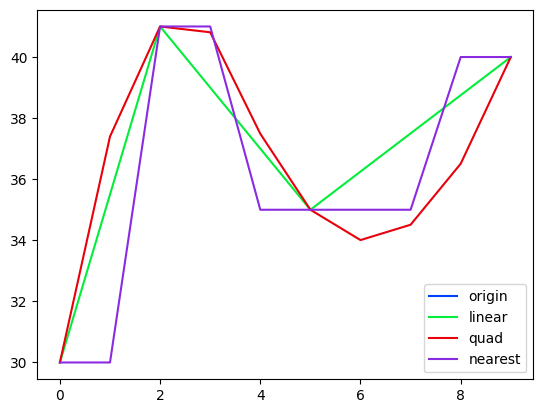

In [39]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-bright')
# Sample DataFrame with missing values
df = pd.Series([30,np.nan,41,np.nan,np.nan,35,np.nan,np.nan,np.nan,40],name = 'Temp')
odf = df.copy()
s1 = odf.interpolate(method = 'linear')
s2 = odf.interpolate(method = 'quadratic')
s3 = odf.interpolate(method = 'nearest')
mdf = pd.concat([df,s1,s2,s3],axis = 1)
mdf.columns = ['origin','linear','quad','nearest']
display(mdf)
mdf.plot()

## from other package

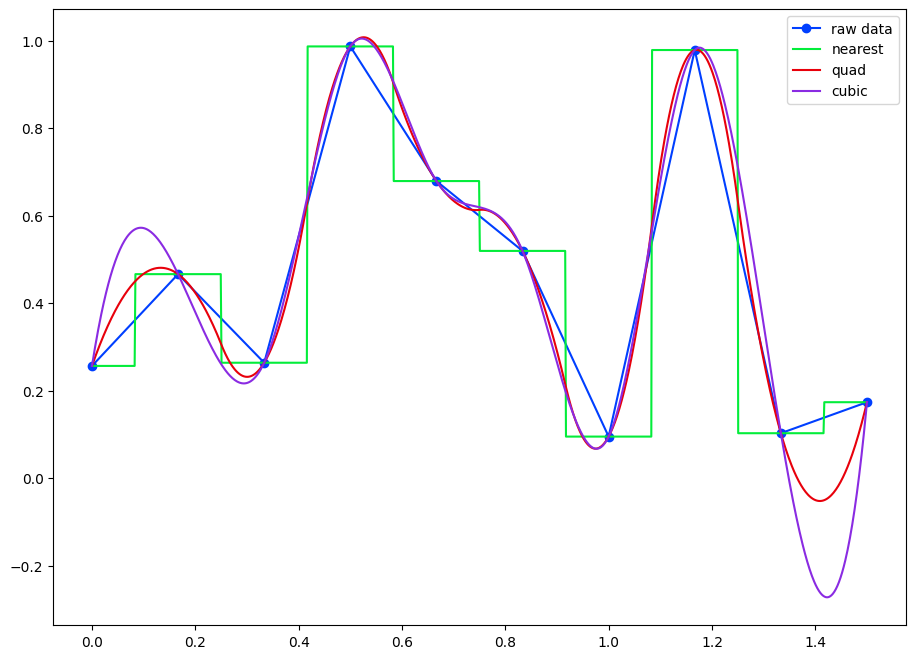

In [40]:
from scipy.interpolate import interp1d
xmin, xmax = 0,1.5
n1, n2 = 10, 1000
x = np.linspace(xmin,xmax,n1)
x1 = np.linspace(xmin,xmax,n2)
y = np.random.rand(n1)
map1 = interp1d(x,y,kind = 'nearest')
map2 = interp1d(x,y,kind = 'quadratic')
map3 = interp1d(x,y,kind = 'cubic')
y1 = map1(x1)
y2 = map2(x1)
y3 = map3(x1)
plt.figure(figsize = [11,8])
plt.plot(x,y,'-o',label = 'raw data')
plt.plot(x1,y1,label = 'nearest')
plt.plot(x1,y2,label = 'quad')
plt.plot(x1,y3,label = 'cubic')
plt.legend()

***
## Sentinel Value
***

**None vs NaN — 兩種缺失值**

| | `None` | `np.nan` |
|--|--------|---------|
| 型別 | Python `NoneType` | IEEE 754 浮點數 |
| NumPy array dtype | `object`（降低效能） | `float64` |
| 算術運算 | 拋出 `TypeError` | 傳播為 `nan` |
| Pandas 行為 | 在數值 Series 中轉換為 `NaN` | 保持 `nan` |

**Gotcha：** NumPy array 中放 `None` 會使整個 array 的 dtype 變成 `object`，
失去向量化效能。應改用 `np.nan`（限數值）或 pandas nullable dtype（`Int32`、`Float64`）。


In [41]:
# None forces NumPy to fall back to object dtype
v1 = np.array([1, None, 2, 3])
display(v1)
try:
    v1.sum()   # object array -> Python-level addition, not fast numeric ops
except Exception as e:
    print(e)


array([1, None, 2, 3], dtype=object)

unsupported operand type(s) for +: 'int' and 'NoneType'


In [42]:
# np.nan is a floating-point sentinel for missing numeric data
v2 = np.array([1, np.nan, 3, 4])
display(v2,
        1 + np.nan,     # nan propagates through arithmetic
        0 * np.nan,
        v2.sum(),       # regular reductions keep nan
        v2.min(),
        np.nansum(v2),  # nan-aware reductions skip missing values
        np.nanmin(v2))


array([ 1., nan,  3.,  4.])

nan

nan

np.float64(nan)

np.float64(nan)

np.float64(8.0)

np.float64(1.0)

In [43]:
# 延伸：偵測 NaN 的正確方式
import numpy as np
import pandas as pd

x = np.nan

# WRONG：x == np.nan 永遠回傳 False
print(x == np.nan)    # False

# CORRECT：用 np.isnan 或 pd.isna
print(np.isnan(x))    # True
print(pd.isna(x))     # True（也能處理 None 和 pd.NA）

# pd.isna 對各種缺失值都有效
print(pd.isna(None))   # True
print(pd.isna(pd.NA))  # True
print(pd.isna(1.0))    # False


False
True
True
True
True
False


***
## NaN and None in Pandas
***

**Pandas 中 NaN 與 None 的統一行為**

Pandas 在**數值 Series** 中會將 `None` 轉換為 `np.nan`（float64）。
因此：

```python
pd.Series([1, np.nan, np.pi, None])
# → dtype: float64，None 自動轉為 NaN


In [44]:
pd.Series([1,np.nan,np.pi,None])

0    1.000000
1         NaN
2    3.141593
3         NaN
dtype: float64

In [45]:
# plain int dtype cannot store missing values without upcasting
x = pd.Series(range(2), dtype=int)
display(x)
x[0] = None   # Series is promoted from int64 to float64
display(x)


0    0
1    1
dtype: int64

0    NaN
1    1.0
dtype: float64

***
## Pandas Nullable Dtype
***

In [46]:
# nullable Int32 keeps integer semantics while allowing missing values
pd.Series([1, np.nan, None, 2, pd.NA], dtype='Int32')


0       1
1    <NA>
2    <NA>
3       2
4    <NA>
dtype: Int32

In [47]:
# 延伸：各種 nullable dtype 比較
import pandas as pd
import numpy as np

# 舊式（float 承擔缺失）
s_old = pd.Series([1, None, 3], dtype='float64')
print(s_old.dtype)    # float64，整數資訊損失

# 新式 nullable（推薦）
s_new = pd.Series([1, pd.NA, 3], dtype='Int64')
print(s_new.dtype)    # Int64（大寫）

# Boolean nullable
s_bool = pd.Series([True, pd.NA, False], dtype='boolean')
print(s_bool)

# 實務上：讀取 CSV 後手動轉換以節省記憶體
# df['count'] = df['count'].astype('Int32')


float64
Int64
0     True
1     <NA>
2    False
dtype: boolean


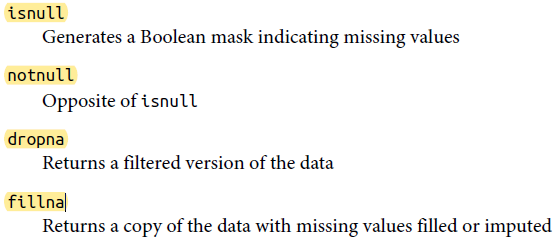

In [48]:
data = pd.Series([1,np.nan,'hello',None])
display(data,
        data.isnull(),
        data[~data.isnull()],
        data[data.notnull()],
        data.dropna())

0        1
1      NaN
2    hello
3     None
dtype: object

0    False
1     True
2    False
3     True
dtype: bool

0        1
2    hello
dtype: object

0        1
2    hello
dtype: object

0        1
2    hello
dtype: object

***
## Dropping Null
***

**`dropna()` — 刪除含缺失值的行/列**

```python
df.dropna(axis=0, how='any')   # 預設：刪除含任一 NaN 的「行」
df.dropna(axis=1, how='all')   # 刪除「全部」都是 NaN 的「欄」
df.dropna(thresh=k)            # 保留至少有 k 個非 NaN 值的行


In [49]:
df = pd.DataFrame([[1, np.nan, 2],
                   [2, 3, 5],
                   [np.nan, 4, 6]])
# dropna() defaults to axis=0, how='any': any missing value drops the row
display(df,
        df.dropna(),
        df.dropna(axis=1))  # axis=1 drops columns with missing values


,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,NaN,4.0,6


,0,1,2
1,2.0,3.0,5


,2
0,2
1,5
2,6


In [50]:
df[3] = np.nan
display(df,
        df.dropna(axis=1, how='all'),   # drop only columns that are all missing
        df.dropna(axis=0, thresh=3))    # keep rows with at least 3 non-null values


,0,1,2,3
0,1.0,NaN,2,NaN
1,2.0,3.0,5,NaN
2,NaN,4.0,6,NaN


,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,NaN,4.0,6


,0,1,2,3
1,2.0,3.0,5,NaN


In [51]:
# 延伸：dropna 前先用 isnull 查看缺失情況
import pandas as pd
import numpy as np

df = pd.DataFrame({'A': [1, np.nan, 3],
                   'B': [np.nan, np.nan, 6],
                   'C': [7, 8, 9]})

# 缺失值地圖
print(df.isnull())

# 各欄缺失數量
print(df.isnull().sum())          # 欄方向：A=1, B=2, C=0

# 缺失比例
print(df.isnull().mean())         # 缺失率：A=0.33, B=0.67, C=0.0

# 實務：只刪缺失率 > 50% 的欄
threshold = len(df) * 0.5
df_clean = df.dropna(axis=1, thresh=int(threshold))
print(df_clean)


       A      B      C
0  False   True  False
1   True   True  False
2  False  False  False
A    1
B    2
C    0
dtype: int64
A    0.333333
B    0.666667
C    0.000000
dtype: float64
     A    B  C
0  1.0  NaN  7
1  NaN  NaN  8
2  3.0  6.0  9


***
## Filling Null
***

**`fillna()` — 填補缺失值**

```python
data.fillna(value)        # 用固定值填補
data.fillna(method='ffill')  # forward fill：用前一個有效值往後填
data.fillna(method='bfill')  # backward fill：用後一個有效值往前填


In [52]:
# fillna(value): replace missing values with a scalar or mapping
data = pd.Series([1, np.nan, 2, None, 3], index=list('abcde'), dtype='Int32')
display(data,
        data.fillna(-1),
        data.ffill(),     # forward fill: use the previous valid value
        data.bfill(),     # backward fill: use the next valid value
        df,
        df.ffill(axis=1)) # fill across columns within each row


a       1
b    <NA>
c       2
d    <NA>
e       3
dtype: Int32

a     1
b    -1
c     2
d    -1
e     3
dtype: Int32

a    1
b    1
c    2
d    2
e    3
dtype: Int32

a    1
b    2
c    2
d    3
e    3
dtype: Int32

,A,B,C
0,1.0,NaN,7
1,NaN,NaN,8
2,3.0,6.0,9


,A,B,C
0,1.0,1.0,7.0
1,NaN,NaN,8.0
2,3.0,6.0,9.0


In [53]:
# 延伸：DataFrame 的 fillna + 欄位各自填補
import pandas as pd
import numpy as np

df = pd.DataFrame({'age':    [25.0, np.nan, 30.0, np.nan],
                   'salary': [50000.0, 60000.0, np.nan, 70000.0]})

# 各欄用該欄的中位數填補（避免 outlier 影響）
df_filled = df.fillna(df.median())
print(df_filled)

# 用 dict 指定每欄的填補值
df_filled2 = df.fillna({'age': df['age'].mean(),
                         'salary': 0})
print(df_filled2)


    age   salary
0  25.0  50000.0
1  27.5  60000.0
2  30.0  60000.0
3  27.5  70000.0
    age   salary
0  25.0  50000.0
1  27.5  60000.0
2  30.0      0.0
3  27.5  70000.0


***
##  Concatenation
***

**`pd.concat()` — 拼接 Series / DataFrame**

```python
pd.concat([df1, df2], axis=0)  # 垂直拼接（預設）
pd.concat([df1, df2], axis=1)  # 水平拼接


In [54]:
ser1 = pd.Series(['A', 'B', 'C'], index=[1, 2, 3])
ser2 = pd.Series(['D', 'E', 'F'], index=[4, 5, 6])
# axis=0 stacks rows; axis=1 places objects side by side as columns
display(pd.concat([ser1, ser2]),
        pd.concat([ser1, ser2], axis=1))


1    A
2    B
3    C
4    D
5    E
6    F
dtype: str

,0,1
1,A,NaN
2,B,NaN
3,C,NaN
4,NaN,D
5,NaN,E
6,NaN,F


In [55]:
def make_df(cols: str,ind: list):
	"Quickly make a DataFrame"
	data = {c:[f'{c}{i}' for i in ind] for c in cols}
	return pd.DataFrame(data,ind)
df1 = make_df('AB',[1,2])
df2 = make_df('AB',[3,4])
display(df1,
		df2,
		pd.concat([df1, df2]))

,A,B
1,A1,B1
2,A2,B2


,A,B
3,A3,B3
4,A4,B4


,A,B
1,A1,B1
2,A2,B2
3,A3,B3
4,A4,B4


In [56]:
df3 = make_df('AB',[0,1])
df4 = make_df('CD',[0,1])
display(df3,
        df4,
        pd.concat([df3,df4],axis = 1))

,A,B
0,A0,B0
1,A1,B1


,C,D
0,C0,D0
1,C1,D1


,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1


In [57]:
x = make_df('AB', [0, 1])
y = make_df('AB', [2, 3])
y.index = x.index   # make indices collide on purpose
display(x,
        y,
        pd.concat([x, y]))
# verify_integrity=True raises an error if the concatenated index overlaps
try:
    pd.concat([x, y], verify_integrity=True)
except ValueError as e:
    print(e)


,A,B
0,A0,B0
1,A1,B1


,A,B
0,A2,B2
1,A3,B3


,A,B
0,A0,B0
1,A1,B1
0,A2,B2
1,A3,B3


Indexes have overlapping values: Index([0, 1], dtype='int64')


In [58]:
# ignore_index=True discards the old row labels and rebuilds 0..n-1
display(x,
        y,
        pd.concat([x, y], ignore_index=True))


,A,B
0,A0,B0
1,A1,B1


,A,B
0,A2,B2
1,A3,B3


,A,B
0,A0,B0
1,A1,B1
2,A2,B2
3,A3,B3


In [59]:
# keys= adds an outer MultiIndex level to record each source object
display(x,
        y,
        pd.concat([x, y], keys=['x', 'y']))


,A,B
0,A0,B0
1,A1,B1


,A,B
0,A2,B2
1,A3,B3


A   B
x 0  A0  B0
  1  A1  B1
y 0  A2  B2
  1  A3  B3

In [60]:
# 延伸：pd.concat axis=1 + 欄名不同時的對齊行為
import pandas as pd

df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'C': [5, 6], 'D': [7, 8]})
df3 = pd.DataFrame({'A': [9, 10, 11], 'B': [12, 13, 14]})  # 多一行

# axis=1：水平拼接（index 對齊）
print(pd.concat([df1, df2], axis=1))     # shape=(2,4)

# 行數不同時，多出的行填 NaN
print(pd.concat([df1, df3], axis=1))     # shape=(3,4)，index 2 的 df1 欄填 NaN

# 只保留共同 index（inner join）
print(pd.concat([df1, df3], axis=1, join='inner'))  # shape=(2,4)


   A  B  C  D
0  1  3  5  7
1  2  4  6  8
     A    B   A   B
0  1.0  3.0   9  12
1  2.0  4.0  10  13
2  NaN  NaN  11  14
   A  B   A   B
0  1  3   9  12
1  2  4  10  13


***
## Categories of Joins
***

**`pd.merge()` — 資料庫風格的 JOIN**

```python
pd.merge(left, right, on='key')             # 同名 key 欄
pd.merge(left, right, left_on='a', right_on='b')  # 不同欄名
pd.merge(left, right, left_index=True, right_index=True)  # 用 index 合併


In [61]:
# One-to-One join: employee is a unique key in both tables
df1 = pd.DataFrame({'employee': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'group': ['Accounting', 'Engineering', 'Engineering', 'HR']})
df2 = pd.DataFrame({'employee': ['Lisa', 'Bob', 'Jake', 'Sue'],
                    'hire_date': [2004, 2008, 2012, 2014]})
df3 = df1.merge(df2)
# merge automatically uses the shared 'employee' column as the key
display(df1,
        df2,
        pd.merge(df1, df2))


,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR


,employee,hire_date
0,Lisa,2004
1,Bob,2008
2,Jake,2012
3,Sue,2014


,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


In [62]:
# Many-to-One: df3 has repeated group values, df4 has one row per group
df4 = pd.DataFrame({'group': ['Accounting', 'Engineering', 'HR'],
                    'supervisor': ['Carly', 'Guido', 'Steve']})
# each employee row is matched to the supervisor of its group
display(df3,
        df4,
        pd.merge(df3, df4))


,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


,group,supervisor
0,Accounting,Carly
1,Engineering,Guido
2,HR,Steve


,employee,group,hire_date,supervisor
0,Bob,Accounting,2008,Carly
1,Jake,Engineering,2012,Guido
2,Lisa,Engineering,2004,Guido
3,Sue,HR,2014,Steve


In [63]:
df5 = pd.DataFrame({'group': ['Accounting','Accounting','Engineering','Engineering','HR','HR'],
                    'skills': ['math','spreadsheets','software','math','spreadsheets','organization']})
display(df1,df5,df1.merge(df5))

,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR


,group,skills
0,Accounting,math
1,Accounting,spreadsheets
2,Engineering,software
3,Engineering,math
4,HR,spreadsheets
5,HR,organization


,employee,group,skills
0,Bob,Accounting,math
1,Bob,Accounting,spreadsheets
2,Jake,Engineering,software
3,Jake,Engineering,math
4,Lisa,Engineering,software
5,Lisa,Engineering,math
6,Sue,HR,spreadsheets
7,Sue,HR,organization


***
## Merge Key
***

In [64]:
# explicitly specify the name of the key column
display(df1,
        df2,
        df1.merge(df2,on = 'employee'))

,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR


,employee,hire_date
0,Lisa,2004
1,Bob,2008
2,Jake,2012
3,Sue,2014


,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


In [65]:
# left_on / right_on handles joins when the key column names differ
df3 = pd.DataFrame({'name': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'salary': [70000, 80000, 120000, 90000]})
display(df1,
        df3,
        pd.merge(df1, df3, left_on='employee', right_on='name'),
        pd.merge(df1, df3, left_on='employee', right_on='name').drop('name', axis=1))


,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR


,name,salary
0,Bob,70000
1,Jake,80000
2,Lisa,120000
3,Sue,90000


,employee,group,name,salary
0,Bob,Accounting,Bob,70000
1,Jake,Engineering,Jake,80000
2,Lisa,Engineering,Lisa,120000
3,Sue,HR,Sue,90000


,employee,group,salary
0,Bob,Accounting,70000
1,Jake,Engineering,80000
2,Lisa,Engineering,120000
3,Sue,HR,90000


In [66]:
# set_index moves the join key into the index for index-based merges
df1a = df1.set_index('employee')
df2a = df2.set_index('employee')
display(df1a,
        df2a,
        pd.merge(df1a, df2a, left_index=True, right_index=True))
# same idea as df1a.join(df2a)


,group
employee,
Bob,Accounting
Jake,Engineering
Lisa,Engineering
Sue,HR


,hire_date
employee,
Lisa,2004
Bob,2008
Jake,2012
Sue,2014


,group,hire_date
employee,,
Bob,Accounting,2008
Jake,Engineering,2012
Lisa,Engineering,2004
Sue,HR,2014


In [67]:
# mix indices and columns, you can combine left_index with right_on
display(df1a,
        df3,
        df1a.merge(df3,left_index = True,right_on = 'name'))

,group
employee,
Bob,Accounting
Jake,Engineering
Lisa,Engineering
Sue,HR


,name,salary
0,Bob,70000
1,Jake,80000
2,Lisa,120000
3,Sue,90000


,group,name,salary
0,Accounting,Bob,70000
1,Engineering,Jake,80000
2,Engineering,Lisa,120000
3,HR,Sue,90000


In [68]:
# join() method, which performs an index-based merge without extra keywords
display(df1.join(df3),
        df1a.join(df2a))

,employee,group,name,salary
0,Bob,Accounting,Bob,70000
1,Jake,Engineering,Jake,80000
2,Lisa,Engineering,Lisa,120000
3,Sue,HR,Sue,90000


,group,hire_date
employee,,
Bob,Accounting,2008
Jake,Engineering,2012
Lisa,Engineering,2004
Sue,HR,2014


In [69]:
df6 = pd.DataFrame({'name':['Peter','Paul','Mary'],
                    'food':['fish','beans','bread']},
                    columns = ['name','food'])
df7 = pd.DataFrame({'name':['Mary','Joseph'],
                    'drink':['wine','beer']},
                    columns = ['name','drink'])
display(df6,
        df7,
        df6.merge(df7), # default is inner join
        df6.merge(df7,how = 'outer'),
        df6.merge(df7,how = 'left'))

,name,food
0,Peter,fish
1,Paul,beans
2,Mary,bread


,name,drink
0,Mary,wine
1,Joseph,beer


,name,food,drink
0,Mary,bread,wine


,name,food,drink
0,Joseph,NaN,beer
1,Mary,bread,wine
2,Paul,beans,NaN
3,Peter,fish,NaN


,name,food,drink
0,Peter,fish,NaN
1,Paul,beans,NaN
2,Mary,bread,wine


In [70]:
# Overlapping column names
df8 = pd.DataFrame({'name':['Bob','Jake','Lisa','Sue'],
                    'rank':[1,2,3,4]})
df9 = pd.DataFrame({'name':['Bob','Jake','Lisa','Sue'],
                    'rank':[3,1,4,2]})
display(df8,
        df9,
        df8.merge(df9,on = 'name'),
        df8.merge(df9,on = 'name',suffixes = [' for L',' for R']))

,name,rank
0,Bob,1
1,Jake,2
2,Lisa,3
3,Sue,4


,name,rank
0,Bob,3
1,Jake,1
2,Lisa,4
3,Sue,2


,name,rank_x,rank_y
0,Bob,1,3
1,Jake,2,1
2,Lisa,3,4
3,Sue,4,2


,name,rank for L,rank for R
0,Bob,1,3
1,Jake,2,1
2,Lisa,3,4
3,Sue,4,2


In [71]:
# 延伸：how='outer'、'left'、'right' 比較
import pandas as pd

left  = pd.DataFrame({'key': ['A', 'B', 'C'], 'val_L': [1, 2, 3]})
right = pd.DataFrame({'key': ['B', 'C', 'D'], 'val_R': [4, 5, 6]})

print('inner：\n', pd.merge(left, right, on='key', how='inner'))
print('left：\n',  pd.merge(left, right, on='key', how='left'))
print('right：\n', pd.merge(left, right, on='key', how='right'))
print('outer：\n', pd.merge(left, right, on='key', how='outer'))

# suffixes：處理合併後欄名衝突
df_a = pd.DataFrame({'key': ['A', 'B'], 'value': [1, 2]})
df_b = pd.DataFrame({'key': ['A', 'B'], 'value': [3, 4]})
print(pd.merge(df_a, df_b, on='key', suffixes=('_left', '_right')))


inner：
   key  val_L  val_R
0   B      2      4
1   C      3      5
left：
   key  val_L  val_R
0   A      1    NaN
1   B      2    4.0
2   C      3    5.0
right：
   key  val_L  val_R
0   B    2.0      4
1   C    3.0      5
2   D    NaN      6
outer：
   key  val_L  val_R
0   A    1.0    NaN
1   B    2.0    4.0
2   C    3.0    5.0
3   D    NaN    6.0
  key  value_left  value_right
0   A           1            3
1   B           2            4


***
## Aggregation
***

**Pandas 常用 Aggregation 函式**

| 函式 | 說明 |
|------|------|
| `df.describe()` | count, mean, std, min, 25%, 50%, 75%, max |
| `df['col'].value_counts()` | 各值的出現次數（降序） |
| `df.info()` | 欄位名稱、非 NaN 數、dtype，快速診斷缺失 |
| `groupby('col').size()` | 各組的行數（**含** NaN） |
| `groupby('col').count()` | 各組的非 NaN 數（**不含** NaN） |

**Gotcha（`size` vs `count`）：**
`size()` 計算每組的**總行數**（含 NaN）；
`count()` 計算每組**每欄**的非 NaN 數。
結果不同！這是考試常考的陷阱。


In [72]:
import seaborn as sns
planets = sns.load_dataset('planets')
display(planets.shape,
        planets.head())

(1035, 6)

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [73]:
# Show the null related info
planets.info()

<class 'pandas.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   str    
 1   number          1035 non-null   int64  
 2   orbital_period  992 non-null    float64
 3   mass            513 non-null    float64
 4   distance        808 non-null    float64
 5   year            1035 non-null   int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 48.6 KB


### Both size and count can be used in combination with groupby. 
### size includes NaN values. 
### count excludes the missing values.

In [74]:
# size counts rows, including missing values; count skips missing entries
mdf = pd.concat([planets.groupby('method')['mass'].size(),
                 planets.groupby('method')['mass'].count()], axis=1)
mdf.columns = ['size', 'count']
mdf


,size,count
method,,
Astrometry,2,0
Eclipse Timing Variations,9,2
Imaging,38,0
Microlensing,23,0
Orbital Brightness Modulation,3,0
Pulsar Timing,5,0
Pulsation Timing Variations,1,0
Radial Velocity,553,510
Transit,397,1


In [75]:
# Values count
planets.mass.value_counts().sort_values(ascending = False)

mass
1.8000    6
1.9000    6
2.6000    5
2.3000    5
1.7000    4
         ..
0.0363    1
0.5000    1
1.3730    1
9.1700    1
1.5400    1
Name: count, Length: 381, dtype: int64

In [76]:
# describe() summarizes numeric columns by default
display(planets.describe(),
        planets.describe(include=['object']))  # include object columns explicitly


/var/folders/gv/755jwkvj1_7gncxqw4flsmch0000gn/T/ipykernel_7646/1767219565.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  planets.describe(include=['object']))  # include object columns explicitly


,number,orbital_period,mass,distance,year
count,1035.000000,992.000000,513.000000,808.000000,1035.000000
mean,1.785507,2002.917596,2.638161,264.069282,2009.070531
std,1.240976,26014.728304,3.818617,733.116493,3.972567
min,1.000000,0.090706,0.003600,1.350000,1989.000000
25%,1.000000,5.442540,0.229000,32.560000,2007.000000
50%,1.000000,39.979500,1.260000,55.250000,2010.000000
75%,2.000000,526.005000,3.040000,178.500000,2012.000000
max,7.000000,730000.000000,25.000000,8500.000000,2014.000000


,method
count,1035
unique,10
top,Radial Velocity
freq,553


In [77]:
# 延伸：常用 aggregation 一覽 + 自訂函式
import pandas as pd
import seaborn as sns

planets = sns.load_dataset('planets')

# 單欄多個 agg 函式
print(planets['distance'].agg(['mean', 'median', 'std', 'count']))

# 多欄不同 agg 函式（dict 語法）
print(planets.agg({'distance': 'mean',
                    'mass': 'median',
                    'year': ['min', 'max']}))

# 用 nunique 查看各欄的唯一值數量（診斷類別欄）
print(planets.nunique())


mean      264.069282
median     55.250000
std       733.116493
count     808.000000
Name: distance, dtype: float64
          distance  mass    year
mean    264.069282   NaN     NaN
median         NaN  1.26     NaN
min            NaN   NaN  1989.0
max            NaN   NaN  2014.0
method             10
number              7
orbital_period    988
mass              381
distance          552
year               23
dtype: int64


***
## Group By
***

**`groupby()` 三步驟：Split → Apply → Combine**

```python
df.groupby('key')['col'].func()


In [78]:
# quantile(3/4) computes Q3 for each method group
planets.groupby('method')['orbital_period'].quantile(3/4)


method
Astrometry                         823.590000
Eclipse Timing Variations         5767.000000
Imaging                          94250.000000
Microlensing                      3550.000000
Orbital Brightness Modulation        0.943908
Pulsar Timing                       98.211400
Pulsation Timing Variations       1170.000000
Radial Velocity                    982.000000
Transit                             16.145700
Transit Timing Variations          108.505500
Name: orbital_period, dtype: float64

In [79]:
# groupby on two keys yields (method, year) tuples plus each subgroup
for (method, year), group in planets.groupby(['method', 'year']):
    if year >= 2013:   # only print groups from 2013 onward
        print(f"{year}: {method}, n={len(group)}")


2013: Astrometry, n=1
2013: Imaging, n=7
2013: Microlensing, n=4
2013: Orbital Brightness Modulation, n=1
2013: Radial Velocity, n=29
2014: Radial Velocity, n=11
2013: Transit, n=75
2014: Transit, n=40
2013: Transit Timing Variations, n=1
2014: Transit Timing Variations, n=1


In [80]:
# Find the descriptive stat in distance for all method
planets.groupby('method')['distance'].describe()

,count,mean,std,min,25%,50%,75%,max
method,,,,,,,,
Astrometry,2.0,17.875000,4.094148,14.98,16.4275,17.875,19.3225,20.77
Eclipse Timing Variations,4.0,315.360000,213.203907,130.72,130.7200,315.360,500.0000,500.00
Imaging,32.0,67.715937,53.736817,7.69,22.1450,40.395,132.6975,165.00
Microlensing,10.0,4144.000000,2076.611556,1760.00,2627.5000,3840.000,4747.5000,7720.00
Orbital Brightness Modulation,2.0,1180.000000,0.000000,1180.00,1180.0000,1180.000,1180.0000,1180.00
Pulsar Timing,1.0,1200.000000,NaN,1200.00,1200.0000,1200.000,1200.0000,1200.00
Pulsation Timing Variations,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Radial Velocity,530.0,51.600208,45.559381,1.35,24.4125,40.445,59.2175,354.00
Transit,224.0,599.298080,913.876990,38.00,200.0000,341.000,650.0000,8500.00


In [81]:
# Dispatch method
planets.groupby('method')['distance'].describe().unstack()

       method                       
count  Astrometry                          2.0
       Eclipse Timing Variations           4.0
       Imaging                            32.0
       Microlensing                       10.0
       Orbital Brightness Modulation       2.0
                                         ...  
max    Pulsar Timing                    1200.0
       Pulsation Timing Variations         NaN
       Radial Velocity                   354.0
       Transit                          8500.0
       Transit Timing Variations        2119.0
Length: 80, dtype: float64

***
## Interquantile Range = IQR = ${Q_3 - Q_1}$
***

In [82]:
# aggregate with lambda: compute Tukey fences based on IQR
# lower bound uses max(..., 0) to avoid negative distances
planets.groupby(['method'])['distance'].aggregate(
    [lambda x: max(x.quantile(1/4) - 1.5 * (x.quantile(3/4) - x.quantile(1/4)), 0),
     'median',
     lambda x: x.quantile(3/4) + 1.5 * (x.quantile(3/4) - x.quantile(1/4))]
)


,<lambda_0>,median,<lambda_1>
method,,,
Astrometry,12.085,17.875,23.66500
Eclipse Timing Variations,0.000,315.360,1053.92000
Imaging,0.000,40.395,298.52625
Microlensing,0.000,3840.000,7927.50000
Orbital Brightness Modulation,1180.000,1180.000,1180.00000
Pulsar Timing,1200.000,1200.000,1200.00000
Pulsation Timing Variations,NaN,NaN,NaN
Radial Velocity,0.000,40.445,111.42500
Transit,0.000,341.000,1325.00000


In [83]:
# Find those distance and orbital are null in Microlensing
planets[(planets.method == 'Microlensing') &
        (planets.orbital_period.isnull() & planets.distance.isnull())]

,method,number,orbital_period,mass,distance,year
902,Microlensing,1,NaN,NaN,NaN,2008
903,Microlensing,1,NaN,NaN,NaN,2008
904,Microlensing,1,NaN,NaN,NaN,2009
907,Microlensing,1,NaN,NaN,NaN,2010
917,Microlensing,1,NaN,NaN,NaN,2004
923,Microlensing,1,NaN,NaN,NaN,2009


In [84]:
# 延伸：named aggregation（pandas 0.25+，更清晰的語法）
import pandas as pd
import seaborn as sns

planets = sns.load_dataset('planets')

result = planets.groupby('method')['distance'].agg(
    dist_mean=('mean' if False else 'mean'),   # 示意，實際用法如下
)

# 正確的 named aggregation 語法
result = planets.groupby('method').agg(
    n_planets=('distance', 'count'),
    dist_mean=('distance', 'mean'),
    dist_median=('distance', 'median'),
    year_min=('year', 'min'),
    year_max=('year', 'max')
)
print(result.sort_values('n_planets', ascending=False).head())

# 篩選特定條件的分組（filter）
# 只保留行星數 >= 50 的發現方法
large_groups = planets.groupby('method').filter(lambda g: len(g) >= 50)
print(large_groups['method'].value_counts())


                           n_planets    dist_mean  dist_median  year_min  \
method                                                                     
Radial Velocity                  530    51.600208       40.445      1989   
Transit                          224   599.298080      341.000      2002   
Imaging                           32    67.715937       40.395      2004   
Microlensing                      10  4144.000000     3840.000      2004   
Eclipse Timing Variations          4   315.360000      315.360      2008   

                           year_max  
method                               
Radial Velocity                2014  
Transit                        2014  
Imaging                        2013  
Microlensing                   2013  
Eclipse Timing Variations      2012  
method
Radial Velocity    553
Transit            397
Name: count, dtype: int64


***
## apply vs transform
***

**`apply` vs `transform` 的差異**

| | `apply` | `transform` |
|--|---------|-------------|
| 輸入 | 每組的 Series（或 DataFrame） | 每組的 Series |
| 輸出長度 | 可以縮減（scalar）或保持 | 必須與輸入**等長** |
| 返回 index | 與分組的 index 對應 | 與**原始 DataFrame 的 index** 相同 |
| 用途 | 計算統計量、回傳縮減結果 | 標準化、填補缺失（保留原始形狀） |

**Gotcha：** `transform` 的結果 index 與原 DataFrame 相同，
可直接當成新欄位加回去（常用在「減去組內平均」這類操作）；
`apply` 的結果 index 是 group key，無法直接對齊回原 DataFrame。


In [85]:
# transform: subtract each value from its group mean while keeping original index
planets.groupby('method')['distance'].transform(
    lambda x: np.abs(x - x.mean())
).sort_values().head(10)


945    0.000000
788    0.000000
787    0.000000
521    0.209792
357    0.240208
496    0.269792
424    0.340208
274    0.369792
319    0.429792
318    0.429792
Name: distance, dtype: float64

In [86]:
# apply is more flexible, but its result index is keyed by groups
planets.groupby('method')['distance'].apply(
    lambda x: np.abs(x - x.mean())
).sort_values().head(10)


method                            
Orbital Brightness Modulation  788    0.000000
                               787    0.000000
Pulsar Timing                  945    0.000000
Radial Velocity                521    0.209792
                               357    0.240208
                               496    0.269792
                               424    0.340208
                               274    0.369792
                               319    0.429792
                               318    0.429792
Name: distance, dtype: float64

In [87]:
abs(planets.loc[planets.method == 'Radial Velocity','distance'].dropna() \
- planets.loc[planets.method == 'Radial Velocity','distance'].mean()).sort_values().head(7)

521    0.209792
357    0.240208
496    0.269792
424    0.340208
274    0.369792
318    0.429792
319    0.429792
Name: distance, dtype: float64

In [88]:
decade = 10 * (planets['year'] // 10)
decade = decade.astype(str) + 's'
planets['decade'] = decade
planets.groupby(['method','decade']).count().unstack().fillna(0)

number                     orbital_period        \
decade                         1980s 1990s  2000s  2010s          1980s 1990s   
method                                                                          
Astrometry                       0.0   0.0    0.0    2.0            0.0   0.0   
Eclipse Timing Variations        0.0   0.0    3.0    6.0            0.0   0.0   
Imaging                          0.0   0.0   20.0   18.0            0.0   0.0   
Microlensing                     0.0   0.0   10.0   13.0            0.0   0.0   
Orbital Brightness Modulation    0.0   0.0    0.0    3.0            0.0   0.0   
Pulsar Timing                    0.0   3.0    1.0    1.0            0.0   3.0   
Pulsation Timing Variations      0.0   0.0    1.0    0.0            0.0   0.0   
Radial Velocity                  1.0  28.0  309.0  215.0            1.0  28.0   
Transit                          0.0   0.0   62.0  335.0            0.0   0.0   
Transit Timing Variations        0.0   0.0    0.0    4.0            0.0   0.0   

                                             mass                      \
decade                         2000s  2010s 1980s 1990s  2000s  2010s   
method                                                                  
Astrometry                       0.0    2.0   0.0   0.0    0.0    0.0   
Eclipse Timing Variations        3.0    6.0   0.0   0.0    1.0    1.0   
Imaging                          9.0    3.0   0.0   0.0    0.0    0.0   
Microlensing                     5.0    2.0   0.0   0.0    0.0    0.0   
Orbital Brightness Modulation    0.0    3.0   0.0   0.0    0.0    0.0   
Pulsar Timing                    1.0    1.0   0.0   0.0    0.0    0.0   
Pulsation Timing Variations      1.0    0.0   0.0   0.0    0.0    0.0   
Radial Velocity                309.0  215.0   1.0  25.0  295.0  189.0   
Transit                         62.0  335.0   0.0   0.0    0.0    1.0   
Transit Timing Variations        0.0    3.0   0.0   0.0    0.0    0.0   

                              distance                      year               \
decade                           1980s 1990s  2000s  2010s 1980s 1990s  2000s   
method                                                                          
Astrometry                         0.0   0.0    0.0    2.0   0.0   0.0    0.0   
Eclipse Timing Variations          0.0   0.0    2.0    2.0   0.0   0.0    3.0   
Imaging                            0.0   0.0   16.0   16.0   0.0   0.0   20.0   
Microlensing                       0.0   0.0    0.0   10.0   0.0   0.0   10.0   
Orbital Brightness Modulation      0.0   0.0    0.0    2.0   0.0   0.0    0.0   
Pulsar Timing                      0.0   0.0    0.0    1.0   0.0   3.0    1.0   
Pulsation Timing Variations        0.0   0.0    0.0    0.0   0.0   0.0    1.0   
Radial Velocity                    1.0  28.0  301.0  200.0   1.0  28.0  309.0   
Transit                            0.0   0.0   44.0  180.0   0.0   0.0   62.0   
Transit Timing Variations          0.0   0.0    0.0    3.0   0.0   0.0    0.0   

                                      
decade                         2010s  
method                                
Astrometry                       2.0  
Eclipse Timing Variations        6.0  
Imaging                         18.0  
Microlensing                    13.0  
Orbital Brightness Modulation    3.0  
Pulsar Timing                    1.0  
Pulsation Timing Variations      0.0  
Radial Velocity                215.0  
Transit                        335.0  
Transit Timing Variations        4.0

In [89]:
# 延伸：transform 用於組內標準化（Z-score）
import pandas as pd
import seaborn as sns

planets = sns.load_dataset('planets')

# 計算各方法組內的 Z-score（標準化）
def zscore(x):
    return (x - x.mean()) / x.std()

planets['dist_zscore'] = (planets
    .groupby('method')['distance']
    .transform(zscore))

# 找出各組內距離最遠的（zscore 最大的）
print(planets.nlargest(5, 'dist_zscore')[['method', 'distance', 'dist_zscore']])

# 實務：apply 回傳 DataFrame（多欄輸出）
def summary(g):
    return pd.Series({'n': len(g),
                      'mean': g.mean(),
                      'cv': g.std() / g.mean()})   # 變異係數

print(planets.groupby('method')['distance'].apply(summary))


              method  distance  dist_zscore
951          Transit   8500.00     8.645258
952          Transit   8500.00     8.645258
181  Radial Velocity    354.00     6.637487
587  Radial Velocity    352.11     6.596003
620  Radial Velocity    307.69     5.621011
method                             
Astrometry                     n          2.000000
                               mean      17.875000
                               cv         0.229043
Eclipse Timing Variations      n          9.000000
                               mean     315.360000
                               cv         0.676065
Imaging                        n         38.000000
                               mean      67.715937
                               cv         0.793562
Microlensing                   n         23.000000
                               mean    4144.000000
                               cv         0.501113
Orbital Brightness Modulation  n          3.000000
                               mean  

## Triangulation
***

In [90]:
geo_measure = pd.DataFrame([[15,34,100],
                            [23.24,60.33,250],
                            [37,70,20]],columns = ['alpha','beta','dist'])
rad = lambda x:(x / 180) * np.pi
tri_est = lambda a,b,d:d * np.sin(rad(a)) * np.sin(rad(b)) / np.sin(rad(b-a))
geo_measure['height'] = geo_measure.apply(lambda x:tri_est(*x),axis = 1)
display(geo_measure)

,alpha,beta,dist,height
0,15.00,34.00,100,44.454524
1,23.24,60.33,250,142.127228
2,37.00,70.00,20,20.766824


***
## Pivot
***

In [91]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**`pivot_table()` — 樞紐分析表**

```python
df.pivot_table(values, index, columns, aggfunc='mean', fill_value=0)


In [92]:
# survival rate = mean of survived (0/1) within each sex
titanic.groupby('sex')[['survived']].mean()


,survived
sex,
female,0.742038
male,0.188908


In [93]:
titanic.groupby(['sex', 'class'])['survived'].aggregate('mean')

sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64

In [94]:
# groupby + unstack is equivalent to a simple pivot table
titanic.groupby(['sex', 'class'], observed=True)['survived'].aggregate('mean').unstack()


class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [95]:
# pivot_table is a compact form of groupby(...).agg(...).unstack()
titanic.pivot_table('survived', index='sex',
                    columns='class',
                    aggfunc='mean')


class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [96]:
# 延伸：多個 aggfunc + margins（加總行/列）
import pandas as pd
import seaborn as sns

titanic = sns.load_dataset('titanic')

# margins=True：加上 'All' 行列（全體平均）
pt = titanic.pivot_table('survived',
                          index='sex',
                          columns='class',
                          aggfunc='mean',
                          margins=True)   # 最右欄/最下行顯示全體均值
print(pt.round(3))

# 多個 values + 多個 aggfunc
pt2 = titanic.pivot_table(
    values=['survived', 'age'],
    index='sex',
    columns='class',
    aggfunc={'survived': 'mean', 'age': 'median'},
    observed=True
)
print(pt2)

# 與 crosstab 的關係（crosstab 是 pivot_table 的特例）
ct = pd.crosstab(titanic['sex'], titanic['class'],
                 values=titanic['survived'], aggfunc='mean')
print(ct.round(3))   # 與 pivot_table 結果相同


class   First  Second  Third    All
sex                                
female  0.968   0.921  0.500  0.742
male    0.369   0.157  0.135  0.189
All     0.630   0.473  0.242  0.384
         age               survived                    
class  First Second Third     First    Second     Third
sex                                                    
female  35.0   28.0  21.5  0.968085  0.921053  0.500000
male    40.0   30.0  25.0  0.368852  0.157407  0.135447
class   First  Second  Third
sex                         
female  0.968   0.921  0.500
male    0.369   0.157  0.135
